# Meningitis con Valores Faltantes - Pre-ML Analysis

**Dataset**: Meningitis Missing Values

**Descripción**: Dataset clínico de pacientes con meningitis que incluye valores faltantes intencionalmente para practicar estrategias de imputación.

**Objetivo ML**: Clasificación - predecir el **Outcome** del paciente (Recovered / Deceased) basándose en características clínicas y de laboratorio.

**Features**: 
- Demográficas: Age, Gender
- Análisis de LCR: WBC_Count, Protein_Level, Glucose_Level, Pathogen_Present
- Análisis de sangre: Hemoglobin, WBC_Blood_Count, Platelets, CRP_Level
- Diagnóstico: Diagnosis (Bacterial/Viral/Unknown)
- Riesgo: Risk_Level (Low/Moderate/High)

**Target**: Outcome (Recovered / Deceased)

**Particularidades**:
- Dataset diseñado con valores faltantes para practicar imputación
- Patient_ID no es predictivo (se debe eliminar)
- Múltiples estrategias de imputación posibles (media, mediana, moda, eliminación)

---

## PASO 1: Cargar dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('mening missing 12.csv')

## PASO 2: Ver estructura

In [2]:
df.head()

,Patient_ID,Age,Gender,WBC_Count,Protein_Level,Glucose_Level,Pathogen_Present,Diagnosis,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level
0,1,101.0,Female,8624.0,16.0,83.0,No,Viral,Recovered,15.0,7269.0,160949.0,71.0,Moderate Risk
1,2,78.0,Male,22623.0,200.0,41.0,No,Unknown,Recovered,18.0,6532.0,371741.0,41.0,High Risk
2,3,8.0,Female,12908.0,39.0,3.0,No,Unknown,Recovered,16.0,7417.0,180403.0,22.0,Moderate Risk
3,4,104.0,Female,15072.0,58.0,36.0,Yes,Bacterial,Recovered,7.0,13792.0,132254.0,48.0,Moderate Risk
4,5,38.0,Female,18623.0,152.0,34.0,Yes,Bacterial,Recovered,5.0,17054.0,134941.0,28.0,High Risk


In [3]:
df.shape

(1200, 14)

In [4]:
df.dtypes.to_frame(name='dtype')

,dtype
Patient_ID,int64
Age,float64
Gender,str
WBC_Count,float64
Protein_Level,float64
Glucose_Level,float64
Pathogen_Present,str
Diagnosis,str
Outcome,str
Hemoglobin,float64


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Patient_ID        1200 non-null   int64  
 1   Age               1193 non-null   float64
 2   Gender            1191 non-null   str    
 3   WBC_Count         1192 non-null   float64
 4   Protein_Level     1190 non-null   float64
 5   Glucose_Level     1192 non-null   float64
 6   Pathogen_Present  1192 non-null   str    
 7   Diagnosis         1188 non-null   str    
 8   Outcome           1190 non-null   str    
 9   Hemoglobin        1181 non-null   float64
 10  WBC_Blood_Count   1190 non-null   float64
 11  Platelets         1188 non-null   float64
 12  CRP_Level         1187 non-null   float64
 13  Risk_Level        1200 non-null   str    
dtypes: float64(8), int64(1), str(5)
memory usage: 131.4 KB


## PASO 3: Valores faltantes

In [6]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Pct': missing_pct
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if not missing_df.empty:
    display(missing_df)

,Missing_Count,Missing_Pct
Hemoglobin,19,1.583333
CRP_Level,13,1.083333
Platelets,12,1.000000
Diagnosis,12,1.000000
Outcome,10,0.833333
WBC_Blood_Count,10,0.833333
Protein_Level,10,0.833333
Gender,9,0.750000
Glucose_Level,8,0.666667
WBC_Count,8,0.666667


## PASO 4: Gráfico simple del target

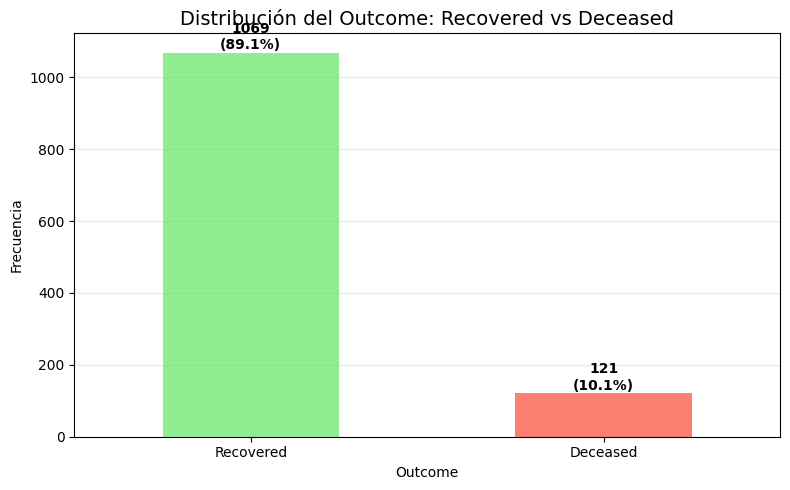

In [7]:
# Distribución del Outcome
outcome_counts = df['Outcome'].value_counts()

plt.figure(figsize=(8, 5))
outcome_counts.plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Distribución del Outcome: Recovered vs Deceased', fontsize=14)
plt.xlabel('Outcome')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Agregar porcentajes
total = len(df)
for i, v in enumerate(outcome_counts):
    plt.text(i, v + 10, f'{v}\n({v/total*100:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## LIMPIEZA

### Eliminar columna Patient_ID (no predictiva)

In [8]:
df = df.drop('Patient_ID', axis=1)

### Estrategia de Imputación

**Análisis de valores faltantes**:
- **Age y Gender**: Variables demográficas con pocos faltantes → usar mediana (Age) y moda (Gender)
- **Otras variables**: Si tienen faltantes, usar mediana para numéricas y moda para categóricas

**Estrategia elegida**: Imputación simple manual (mediana/moda)

In [9]:
# Copiar para no modificar original
df_clean = df.copy()

# Imputar Age con mediana
if df_clean['Age'].isnull().sum() > 0:
    age_median = df_clean['Age'].median()
    df_clean['Age'].fillna(age_median, inplace=True)
    print(f"Age: Imputados {df['Age'].isnull().sum()} valores con mediana = {age_median}")

# Imputar Gender con moda
if df_clean['Gender'].isnull().sum() > 0:
    gender_mode = df_clean['Gender'].mode()[0]
    df_clean['Gender'].fillna(gender_mode, inplace=True)
    print(f"Gender: Imputados {df['Gender'].isnull().sum()} valores con moda = {gender_mode}")

# Verificar si quedan otros valores faltantes
remaining_missing = df_clean.isnull().sum().sum()
print(f"\nValores faltantes restantes: {remaining_missing}")

Age: Imputados 7 valores con mediana = 43.0
Gender: Imputados 9 valores con moda = Male

Valores faltantes restantes: 126


/tmp/ipykernel_1734574/3359650847.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean['Age'].fillna(age_median, inplace=True)
/tmp/ipykernel_1734574/3359650847.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never w

### Verificar outliers (opcional - solo inspección visual)

In [10]:
df_clean.describe()

,Age,WBC_Count,Protein_Level,Glucose_Level,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level
count,1193.000000,1192.000000,1190.000000,1192.000000,1181.000000,1190.000000,1188.000000,1187.000000
mean,47.432523,12130.966443,109.463866,52.633389,9.998307,11295.922689,201626.741582,27.497051
std,24.571305,5670.489634,72.122291,34.695494,5.577193,4956.524846,90936.534040,26.373065
min,0.000000,2017.000000,0.000000,0.000000,1.000000,4013.000000,100204.000000,0.000000
25%,29.000000,7007.250000,43.000000,26.000000,5.000000,6746.750000,125491.250000,3.000000
50%,43.000000,12282.000000,108.000000,53.000000,12.000000,9782.500000,161890.500000,25.000000
75%,61.000000,16895.750000,167.000000,66.000000,15.000000,15806.250000,275962.250000,42.000000
max,119.000000,24947.000000,297.000000,149.000000,18.000000,19988.000000,399110.000000,99.000000


---
## PREPROCESAMIENTO

### Encoding

Variables categóricas detectadas:
- **Nominales** (One-Hot): Gender, Pathogen_Present, Diagnosis
- **Ordinal**: Risk_Level (Low < Moderate < High)
- **Target**: Outcome (Recovered/Deceased)

In [11]:
# 1. Target encoding: Outcome -> 0 (Recovered), 1 (Deceased)
df_clean['Outcome'] = (df_clean['Outcome'] == 'Deceased').astype(int)

# 2. Ordinal encoding: Risk_Level
risk_mapping = {'Low Risk': 0, 'Moderate Risk': 1, 'High Risk': 2}
df_clean['Risk_Level'] = df_clean['Risk_Level'].map(risk_mapping)

# 3. One-Hot encoding manual para Gender
gender_dummies = pd.get_dummies(df_clean['Gender'], prefix='Gender', drop_first=True, dtype=int)
df_clean = pd.concat([df_clean, gender_dummies], axis=1)
df_clean = df_clean.drop('Gender', axis=1)

# 4. One-Hot encoding manual para Pathogen_Present
pathogen_dummies = pd.get_dummies(df_clean['Pathogen_Present'], prefix='Pathogen', drop_first=True, dtype=int)
df_clean = pd.concat([df_clean, pathogen_dummies], axis=1)
df_clean = df_clean.drop('Pathogen_Present', axis=1)

# 5. One-Hot encoding manual para Diagnosis
diagnosis_dummies = pd.get_dummies(df_clean['Diagnosis'], prefix='Diagnosis', drop_first=False, dtype=int)
df_clean = pd.concat([df_clean, diagnosis_dummies], axis=1)
df_clean = df_clean.drop('Diagnosis', axis=1)

print("Encoding completado")
df_clean.head()

Encoding completado


,Age,WBC_Count,Protein_Level,Glucose_Level,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level,Gender_Male,Pathogen_Yes,Diagnosis_Bacterial,Diagnosis_Unknown,Diagnosis_Viral
0,101.0,8624.0,16.0,83.0,0,15.0,7269.0,160949.0,71.0,1,0,0,0,0,1
1,78.0,22623.0,200.0,41.0,0,18.0,6532.0,371741.0,41.0,2,1,0,0,1,0
2,8.0,12908.0,39.0,3.0,0,16.0,7417.0,180403.0,22.0,1,0,0,0,1,0
3,104.0,15072.0,58.0,36.0,0,7.0,13792.0,132254.0,48.0,1,0,1,1,0,0
4,38.0,18623.0,152.0,34.0,0,5.0,17054.0,134941.0,28.0,2,0,1,1,0,0


### Separar features (X) y target (y)

In [12]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nColumnas en X:")
print(X.columns.tolist())

X shape: (1200, 14)
y shape: (1200,)

Columnas en X:
['Age', 'WBC_Count', 'Protein_Level', 'Glucose_Level', 'Hemoglobin', 'WBC_Blood_Count', 'Platelets', 'CRP_Level', 'Risk_Level', 'Gender_Male', 'Pathogen_Yes', 'Diagnosis_Bacterial', 'Diagnosis_Unknown', 'Diagnosis_Viral']


### Train/Test Split Manual (80-20)

In [13]:
# Fijar semilla
np.random.seed(42)

# Crear índices aleatorios
n = len(X)
indices = np.random.permutation(n)

# Split 80-20
split_idx = int(0.8 * n)
train_idx = indices[:split_idx]
test_idx = indices[split_idx:]

# Separar datos
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f"Train size: {len(X_train)} ({len(X_train)/n*100:.1f}%)")
print(f"Test size: {len(X_test)} ({len(X_test)/n*100:.1f}%)")

Train size: 960 (80.0%)
Test size: 240 (20.0%)


### Convertir a float ANTES del escalado

In [14]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

### Feature Scaling Manual (Standardization)

In [15]:
# Calcular media y std del train
train_mean = X_train.mean()
train_std = X_train.std()

# Aplicar scaling
X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

# Asegurar tipo float después de scaling
X_train_scaled = X_train_scaled.astype(float)
X_test_scaled = X_test_scaled.astype(float)

print("Escalado completado")
print(f"Train mean (después): {X_train_scaled.mean().mean():.6f}")
print(f"Train std (después): {X_train_scaled.std().mean():.6f}")

Escalado completado
Train mean (después): -0.000000
Train std (después): 1.000000


---
## VALIDACIÓN

### 1. Verificar Data Leakage

In [16]:
# Verificar que no hay índices compartidos
train_indices = set(X_train.index)
test_indices = set(X_test.index)
overlap = train_indices.intersection(test_indices)

print(f"Índices en train: {len(train_indices)}")
print(f"Índices en test: {len(test_indices)}")
print(f"Overlap: {len(overlap)}")
print(f"✓ Sin data leakage" if len(overlap) == 0 else "✗ HAY DATA LEAKAGE")

Índices en train: 960
Índices en test: 240
Overlap: 0
✓ Sin data leakage


### 2. Verificar NaN e infinitos

In [17]:
# Verificar NaN
train_nan = X_train_scaled.isnull().sum().sum()
test_nan = X_test_scaled.isnull().sum().sum()

# Verificar infinitos
train_inf = np.isinf(X_train_scaled).sum().sum()
test_inf = np.isinf(X_test_scaled).sum().sum()

print(f"Train - NaN: {train_nan}, Inf: {train_inf}")
print(f"Test - NaN: {test_nan}, Inf: {test_inf}")
print(f"✓ Sin problemas" if (train_nan + test_nan + train_inf + test_inf) == 0 else "✗ HAY PROBLEMAS")

Train - NaN: 70, Inf: 0
Test - NaN: 17, Inf: 0
✗ HAY PROBLEMAS


### 3. Comparar distribuciones Train vs Test

In [18]:
# Distribución del target
train_target_dist = y_train.value_counts(normalize=True).sort_index()
test_target_dist = y_test.value_counts(normalize=True).sort_index()

comparison = pd.DataFrame({
    'Train': train_target_dist,
    'Test': test_target_dist
})

comparison.index = ['Recovered (0)', 'Deceased (1)']
comparison

,Train,Test
Recovered (0),0.901042,0.891667
Deceased (1),0.098958,0.108333


---
## RESUMEN FINAL

In [19]:
print("="*60)
print("DATASET PREPARADO PARA ML")
print("="*60)
print(f"\nDatos originales: {len(df)} filas")
print(f"Datos limpios: {len(df_clean)} filas")
print(f"Features: {X_train_scaled.shape[1]}")
print(f"\nTrain: {X_train_scaled.shape}")
print(f"Test: {X_test_scaled.shape}")
print(f"\nClases:")
print(f"  - Recovered (0): {(y_train == 0).sum()} train, {(y_test == 0).sum()} test")
print(f"  - Deceased (1): {(y_train == 1).sum()} train, {(y_test == 1).sum()} test")
print(f"\nEstrategia de imputación: Mediana (numéricas) / Moda (categóricas)")
print("\n" + "="*60)

DATASET PREPARADO PARA ML

Datos originales: 1200 filas
Datos limpios: 1200 filas
Features: 14

Train: (960, 14)
Test: (240, 14)

Clases:
  - Recovered (0): 865 train, 214 test
  - Deceased (1): 95 train, 26 test

Estrategia de imputación: Mediana (numéricas) / Moda (categóricas)

